In [1]:
#https://catalog.data.gov/dataset/alternative-fueling-station-locations-422f2 
# data from above website 
#

In [1]:
#from shapely.geometry import Point
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import seaborn as sns
from folium.plugins import MarkerCluster
from folium.plugins import FastMarkerCluster
#pd.set_option('display.max_columns', None)

In [3]:
#alternate_fuel_stations_df = gpd.read_file('C:/Users/nainy/Documents/nss_dda16/python/projects/EV_Capstone_project_nainy/data/04232015altfuelstations.csv')

In [4]:
#alternate_fuel_stations_df.info()

In [5]:
#alternate_fuel_stations_df.head(3)

In [6]:
alt_fuel_stations_df= gpd.read_file("C:/Users/nainy/Documents/nss_dda16/python/projects/EV_Capstone_project_nainy/data/alt_fuel_stations_Jul_29_2021.csv")

In [96]:
alt_fuel_stations_df

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
0,CNG,Spire - Montgomery Operations Center,2951 Chestnut St,,Montgomery,AL,36107,,,E,,Private,,,,B,3600,,,,,,,200-9,32.367916,-86.267021,2020-11-09,17,2021-07-29 15:08:10 UTC,T,,,2010-12-01,,MD,,,,US,,,,PrivÃ©,,private,,,STANDALONE_STATION,,,,,,,,,,,,B,3600,MD,,,,None
1,CNG,PS Energy - Atlanta,340 Whitehall St,"From I-7585 N, exit 91 to Central Ave, left on...",Atlanta,GA,30303,,770-350-3000,E,,Public - Card key at all times,24 hours daily,Comdata FleetOne FuelMan Voyager Wright_Exp,,Q,3600,,,,,,,200-8,33.745843,-84.398837,2020-10-09,42,2021-07-26 13:24:55 UTC,P,,,1994-07-15,,MD,,,,US,,,,Public - Carte-clÃ© en tout temps,,public,KEY_ALWAYS,,STANDALONE_STATION,1,,30,,,,,,,,,Q,3600,MD,,,,None
2,CNG,Metropolitan Atlanta Rapid Transit Authority,2424 Piedmont Rd NE,,Atlanta,GA,30324,,,E,,Private - Government only,,,,Q,3000,,,,,,,200-8,33.821911,-84.367461,2020-03-03,45,2021-07-27 21:03:31 UTC,LG,,,1996-12-15,,LD,,,,US,,,,PrivÃ© - RÃ©servÃ© au gouvernement,,private,GOVERNMENT,,FLEET_GARAGE,,,30,,,,,,,,,Q,3000,LD,,,,None
3,CNG,United Parcel Service,270 Marvin Miller Dr,,Atlanta,GA,30336,,,E,,Private,,,,B,3600,,,,,,,200-9,33.760256,-84.543822,2021-04-08,64,2021-04-08 20:32:57 UTC,P,,,1997-01-01,,HD,,,,US,,,,PrivÃ©,,private,,,STANDALONE_STATION,,,,,,,,,,,,B,3600,HD,,,,None
4,CNG,Clean Energy - Texas Department of Transportation,7721A Washington St,"I-10, Washington Ave exit, 1.5 blocks to the s...",Houston,TX,77007,,866-809-4869,E,,Public - Credit card at all times,24 hours daily; call 866-809-4869 for Clean En...,CleanEnergy D FuelMan M V Voyager Wright_Exp,,Q,3000 3600,,,,,,,200-9,29.779918,-95.435385,2021-01-14,72,2021-07-20 14:30:28 UTC,P,,,1996-12-15,,MD,,,,US,,,,Public - Carte de crÃ©dit en tout temps,,public,CREDIT_CARD_ALWAYS,,STATE_GOV,2,,420,,,,,,,,,Q,3000 3600,MD,,,,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56795,E85,Sheetz Store #713,10515 Sharpsburg Pk,,Hagerstown,MD,21740,,240-513-7047,E,,Public,24 hours daily,A Cash CREDIT D Debit M V,,,,,,,,,,200-9,39.602267,-77.729039,,193305,2021-07-29 03:49:43 UTC,P,,,2021-07-28,,,,true,,US,,,,Public,,public,,,CONVENIENCE_STORE,,,,,,"[""E15""]",,,,,,,,,,,,None
56796,E85,Kwik Trip #1062,1580 E Washington St,,West Bend,WI,53095,,262-334-0999,E,,Public,24 hours daily,A Cash CREDIT D Debit M V,,,,,,,,,,200-8,43.426952,-88.158696,,193306,2021-07-29 11:24:30 UTC,P,,,2021-07-29,,,,true,,US,,,,Public,,public,,,CONVENIENCE_STORE,,,,,,"[""E15"", ""E40-Plus""]",,,,,,,,,,,,None
56797,E85,76,675 N Lake Ave,,Pasadena,CA,91101,,626-578-1519,E,,Public,24 hours daily,A Cash CREDIT D Debit M V,,,,,,,,,,200-9,34.157522,-118.132898,,193307,2021-07-29 11:52:29 UTC,P,,,2021-07-29,,,,false,,US,,,,Public,,pub

In [7]:
alt_fuel_stations_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 56800 entries, 0 to 56799
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Fuel Type Code                    56800 non-null  object  
 1   Station Name                      56800 non-null  object  
 2   Street Address                    56800 non-null  object  
 3   Intersection Directions           56800 non-null  object  
 4   City                              56800 non-null  object  
 5   State                             56800 non-null  object  
 6   ZIP                               56800 non-null  object  
 7   Plus4                             56800 non-null  object  
 8   Station Phone                     56800 non-null  object  
 9   Status Code                       56800 non-null  object  
 10  Expected Date                     56800 non-null  object  
 11  Groups With Access Code           56800 non-nu

In [8]:
alt_fuel_stations_df['Fuel Type Code'].value_counts()

Fuel Type Code
ELEC    47086
E85      4233
LPG      2893
CNG      1569
BD        726
LNG       150
HY        143
Name: count, dtype: int64

In [9]:
#pie chart

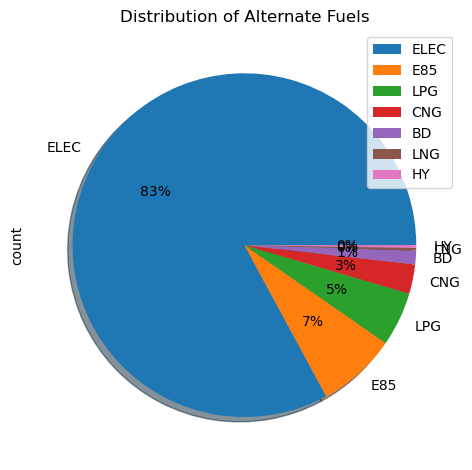

In [10]:
df = alt_fuel_stations_df
df_count = df['Fuel Type Code'].value_counts()
df_count.plot(kind='pie',autopct='%1.0f%%', shadow=True)
plt.title('Distribution of Alternate Fuels') 
plt.legend(loc="upper right")
#ax.legend(labels, title="Categories", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [11]:
Elec_stations_df= alt_fuel_stations_df.loc[alt_fuel_stations_df['Fuel Type Code']== 'ELEC']

In [12]:
Elec_stations_df.shape

(47086, 66)

In [13]:
Elec_stations_df.head(3)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
159,ELEC,LADWP - Truesdale Center,11797 Truesdale St,,Sun Valley,CA,91352,,,E,...,,,,,,,,,,None
160,ELEC,LADWP - West LA District Office,1394 S Sepulveda Blvd,,Los Angeles,CA,90024,,,E,...,,,,,,,,,,None
161,ELEC,Southern California Edison - Rosemead Office B...,2244 Walnut Grove Ave,,Rosemead,CA,91770,,,T,...,,,,,,,,,,None


In [14]:
Elec_stations_df.to_csv('Elec_stations_df.csv', index=False)

In [15]:
Elec_stations_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 47086 entries, 159 to 56793
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Fuel Type Code                    47086 non-null  object  
 1   Station Name                      47086 non-null  object  
 2   Street Address                    47086 non-null  object  
 3   Intersection Directions           47086 non-null  object  
 4   City                              47086 non-null  object  
 5   State                             47086 non-null  object  
 6   ZIP                               47086 non-null  object  
 7   Plus4                             47086 non-null  object  
 8   Station Phone                     47086 non-null  object  
 9   Status Code                       47086 non-null  object  
 10  Expected Date                     47086 non-null  object  
 11  Groups With Access Code           47086 non-null 

In [16]:
Elec_stations_df.shape

(47086, 66)

In [17]:
Elec_stations_df.groupby('State')['ID'].count()

State
AK       40
AL      257
AR      144
AZ      804
CA    13892
CO     1488
CT      517
DC      278
DE      114
FL     2506
GA     1548
HI      393
IA      246
ID      136
IL      996
IN      341
KS      481
KY      177
LA      158
MA     1889
MD     1173
ME      271
MI      781
MN      561
MO     1013
MS      110
MT       69
NC     1046
ND       56
NE      160
NH      152
NJ      712
NM      171
NV      449
NY     2756
OH      841
OK      295
OR      942
PA     1081
PR        5
RI      228
SC      376
SD       50
TN      676
TX     2199
UT      846
VA     1025
VT      312
WA     1686
WI      471
WV      104
WY       64
Name: ID, dtype: int64

In [18]:
Elec_stations_df['State'].value_counts().sort_values(ascending = False)

State
CA    13892
NY     2756
FL     2506
TX     2199
MA     1889
WA     1686
GA     1548
CO     1488
MD     1173
PA     1081
NC     1046
VA     1025
MO     1013
IL      996
OR      942
UT      846
OH      841
AZ      804
MI      781
NJ      712
TN      676
MN      561
CT      517
KS      481
WI      471
NV      449
HI      393
SC      376
IN      341
VT      312
OK      295
DC      278
ME      271
AL      257
IA      246
RI      228
KY      177
NM      171
NE      160
LA      158
NH      152
AR      144
ID      136
DE      114
MS      110
WV      104
MT       69
WY       64
ND       56
SD       50
AK       40
PR        5
Name: count, dtype: int64

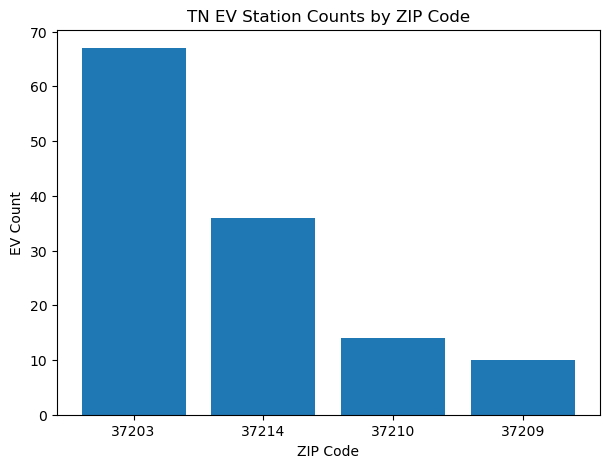

In [19]:
count_zips = {
    37203: 67,
    37214: 36,
    37210: 14,
    37209: 10
}

# If it's a dictionary → convert to Series
import pandas as pd
count_zips = pd.Series(count_zips)

# Bar chart
plt.figure(figsize=(7,5))
plt.bar(count_zips.index.astype(str), count_zips.values)

plt.title("TN EV Station Counts by ZIP Code")
plt.xlabel("ZIP Code")
plt.ylabel("EV Count")
plt.show()

In [20]:
#do a tree map for the showing the largest

In [21]:
#TN_electric_stations

In [22]:
TN_electric_stations = Elec_stations_df.loc[Elec_stations_df['State']== 'TN']

In [23]:
TN_electric_stations.head(3)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
2831,ELEC,METRO NASHVILLE FULTON GARAGE 1,800 2nd Avenue South,,Nashville,TN,37210,,888-758-4389,E,...,,,,,,,,,,None
3521,ELEC,Oak Ridge Nissan,101 S Illinois Ave,,Oak Ridge,TN,37830,,865-482-5489,E,...,,,,,,,,,,None
3522,ELEC,Newton Nissan South,2801 Highway 231 N,,Shelbyville,TN,37160,,931-684-6811,E,...,,,,,,,,,,None


In [24]:
TN_electric_stations.isna().sum()

Fuel Type Code                   0
Station Name                     0
Street Address                   0
Intersection Directions          0
City                             0
                              ... 
CNG Vehicle Class                0
LNG Vehicle Class                0
EV On-Site Renewable Source      0
Restricted Access                0
geometry                       676
Length: 66, dtype: int64

In [25]:
#pd.set_option('display.max_rows', None)

In [26]:
TN_electric_stations.shape

(676, 66)

In [27]:
TN_electric_stations['ZIP'].value_counts().sort_values(ascending = False)
# Davidson County has more Public electric chargers.

ZIP
37203    62
37214    36
37027    29
37830    21
37129    20
         ..
37745     1
37415     1
37381     1
37076     1
37725     1
Name: count, Length: 160, dtype: int64

In [28]:
TN_electric_stations.head(2)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
2831,ELEC,METRO NASHVILLE FULTON GARAGE 1,800 2nd Avenue South,,Nashville,TN,37210,,888-758-4389,E,...,,,,,,,,,,None
3521,ELEC,Oak Ridge Nissan,101 S Illinois Ave,,Oak Ridge,TN,37830,,865-482-5489,E,...,,,,,,,,,,None


In [29]:
TN_electric_stations.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 676 entries, 2831 to 56785
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Fuel Type Code                    676 non-null    object  
 1   Station Name                      676 non-null    object  
 2   Street Address                    676 non-null    object  
 3   Intersection Directions           676 non-null    object  
 4   City                              676 non-null    object  
 5   State                             676 non-null    object  
 6   ZIP                               676 non-null    object  
 7   Plus4                             676 non-null    object  
 8   Station Phone                     676 non-null    object  
 9   Status Code                       676 non-null    object  
 10  Expected Date                     676 non-null    object  
 11  Groups With Access Code           676 non-null    

In [30]:
print(TN_electric_stations.crs)

None


In [31]:
zipcodes = gpd.read_file('../data/zipcodes.geojson')

In [32]:
print(zipcodes.crs)
zipcodes.head( )

EPSG:4326


,zip,objectid,po_name,shape_stlength,shape_starea,geometry
0,37115,1,MADISON,178783.02488886821,596553400.57885742,"MULTIPOLYGON (((-86.68725 36.31821, -86.68722 ..."
1,37216,3,NASHVILLE,75820.997821400058,188884682.28344727,"MULTIPOLYGON (((-86.73451 36.23774, -86.73425 ..."
2,37204,9,NASHVILLE,93180.292250425613,200664795.51708984,"MULTIPOLYGON (((-86.77914 36.13424, -86.77923 ..."
3,37027,11,BRENTWOOD,159760.6942933173,174978422.04101562,"MULTIPOLYGON (((-86.81258 36.06319, -86.81263 ..."
4,37064,18,FRANKLIN,28995.828320601937,46969608.005737305,"MULTIPOLYGON (((-87.02197 36.01200, -87.02140 ..."


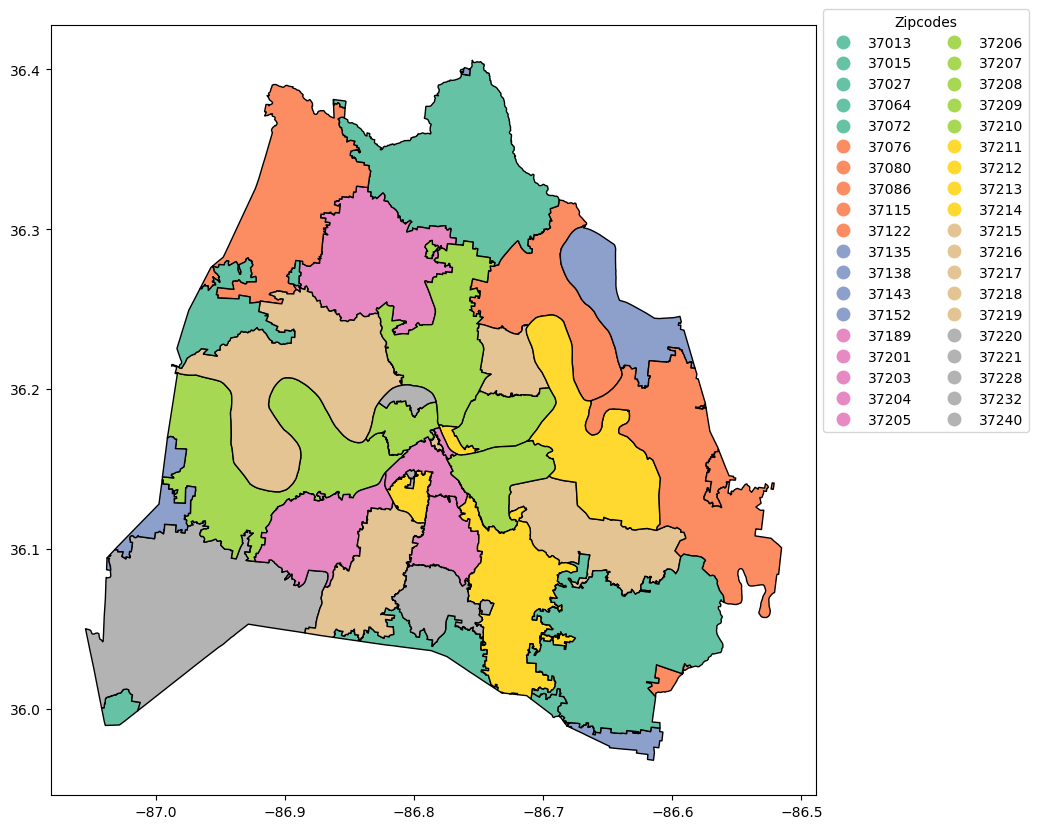

In [33]:
#geopandas will take care of legend styling if you pass a dict of keywords

leg_kwds = {'title': 'Zipcodes', 'loc': 'upper left', 
            'bbox_to_anchor': (1, 1.03), 'ncol': 2}

zipcodes.plot(column = 'zip', figsize=(10, 10),
              edgecolor = 'black',
              legend = True, legend_kwds = leg_kwds, 
              cmap = 'Set2')
plt.show()

In [34]:
TN_electric_stations_geo = gpd.GeoDataFrame(TN_electric_stations, 
                           crs = zipcodes.crs, 
                           geometry = gpd.points_from_xy(TN_electric_stations.Longitude, TN_electric_stations.Latitude))

In [35]:
TN_electric_stations_geo.head(3)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
2831,ELEC,METRO NASHVILLE FULTON GARAGE 1,800 2nd Avenue South,,Nashville,TN,37210,,888-758-4389,E,...,,,,,,,,,,POINT (-86.76732 36.15349)
3521,ELEC,Oak Ridge Nissan,101 S Illinois Ave,,Oak Ridge,TN,37830,,865-482-5489,E,...,,,,,,,,,,POINT (-84.26805 36.01028)
3522,ELEC,Newton Nissan South,2801 Highway 231 N,,Shelbyville,TN,37160,,931-684-6811,E,...,,,,,,,,,,POINT (-86.44828 35.55837)


In [36]:
TN_electric_stations_geo.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
TN_electric_stations_geo['Access Code'].value_counts()

Access Code
public     586
private     90
Name: count, dtype: int64

In [39]:
TN_electric_stations_geo.shape

(676, 66)

In [40]:
TN_electric_stations_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 676 entries, 2831 to 56785
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Fuel Type Code                    676 non-null    object  
 1   Station Name                      676 non-null    object  
 2   Street Address                    676 non-null    object  
 3   Intersection Directions           676 non-null    object  
 4   City                              676 non-null    object  
 5   State                             676 non-null    object  
 6   ZIP                               676 non-null    object  
 7   Plus4                             676 non-null    object  
 8   Station Phone                     676 non-null    object  
 9   Status Code                       676 non-null    object  
 10  Expected Date                     676 non-null    object  
 11  Groups With Access Code           676 non-null    

In [41]:
#pd.TN_electric_stations_geo.to_csv()("TN_electric_stations_geo.csv")

In [42]:
TN_electric_stations_geo.head(3)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
2831,ELEC,METRO NASHVILLE FULTON GARAGE 1,800 2nd Avenue South,,Nashville,TN,37210,,888-758-4389,E,,Public,24 hours daily,,,,,,1,,,ChargePoint Network,http://www.chargepoint.com/,GPS,36.153492,-86.76732,2021-07-29,35165,2021-07-29 00:26:39 UTC,,,,2009-08-15,,,,,J1772,US,,,,Public,,public,,,,,,,,,,,,,,,,,,,,,POINT (-86.76732 36.15349)
3521,ELEC,Oak Ridge Nissan,101 S Illinois Ave,,Oak Ridge,TN,37830,,865-482-5489,E,,Public - Call ahead,Dealership business hours,,,,,,1,,,Non-Networked,,200-9,36.010279,-84.268049,2020-06-09,39705,2021-03-11 23:22:17 UTC,P,,,2011-03-15,,,,,J1772,US,,,,Public - Appeler Ã l'avance,,public,CALL,,CAR_DEALER,,,,,,,Free,,,,,,,,,,,POINT (-84.26805 36.01028)
3522,ELEC,Newton Nissan South,2801 Highway 231 N,,Shelbyville,TN,37160,,931-684-6811,E,,Public - Call ahead,Dealership business hours,,,,,,1,,,Non-Networked,,200-9,35.558371,-86.448276,2020-06-09,39707,2021-03-11 23:22:17 UTC,P,,,2011-03-15,,,,,J1772,US,,,,Public - Appeler Ã l'avance,,public,CALL,,CAR_DEALER,,,,,,,Free,,,,,,,,,,,POINT (-86.44828 35.55837)


In [43]:
TN_electric_stations_geo.groupby('ZIP')['ID'].count().sort_values(ascending = False)

ZIP
37203    62
37214    36
37027    29
37830    21
37863    20
         ..
37419     1
37415     1
37410     1
37398     1
38585     1
Name: ID, Length: 160, dtype: int64

In [44]:
# both crs are a match.

In [45]:
zipcodes = zipcodes[['zip', 'po_name', 'geometry']]
#pulling up the zip code

In [46]:
stops_by_zip = gpd.sjoin(TN_electric_stations_geo, zipcodes, predicate = 'within')

In [47]:
stops_by_zip.shape

(211, 69)

In [48]:
stops_by_zip.head(3)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry,index_right,zip,po_name
2831,ELEC,METRO NASHVILLE FULTON GARAGE 1,800 2nd Avenue South,,Nashville,TN,37210,,888-758-4389,E,,Public,24 hours daily,,,,,,1,,,ChargePoint Network,http://www.chargepoint.com/,GPS,36.153492,-86.76732,2021-07-29,35165,2021-07-29 00:26:39 UTC,,,,2009-08-15,,,,,J1772,US,,,,Public,,public,,,,,,,,,,,,,,,,,,,,,POINT (-86.76732 36.15349),47,37210,NASHVILLE
3614,ELEC,Nissan of Rivergate,1550 Gallatin Pike N,,Madison,TN,37115,,615-865-7220,E,,Public - Call ahead,Dealership business hours,,,,,,1,1,,Non-Networked,,GPS,36.29062,-86.7051,2020-06-09,39815,2021-03-11 23:22:17 UTC,P,,,2019-05-01,,,,,CHADEMO J1772,US,,,,Public - Appeler Ã l'avance,,public,CALL,,CAR_DEALER,,,,,,,Free,,,,,,,,,,,POINT (-86.70510 36.29062),0,37115,MADISON
3621,ELEC,Action Nissan,307 Thompson Ln,,Nashville,TN,37211,,615-834-8244,E,,Public - Call ahead,Dealership business hours,,,,,,2,1,,Non-Networked,,200-9,36.110606,-86.743585,2020-06-09,39822,2021-03-11 23:22:17 UTC,P,,,2011-03-15,,,,,CHADEMO J1772,US,,,,Public - Appeler Ã l'avance,,public,CALL,,CAR_DEALER,,,,,,,Free,,,,,,,,,,,POINT (-86.74358 36.11061),49,37211,NASHVILLE


In [49]:
len(stops_by_zip)

211

In [50]:
count_zips= stops_by_zip['zip'].value_counts()
count_zips.reset_index()

,zip,count
0,37203,67
1,37214,36
2,37210,14
3,37209,10
4,37201,9
5,37212,8
6,37221,8
7,37027,7
8,37013,7
9,37115,6


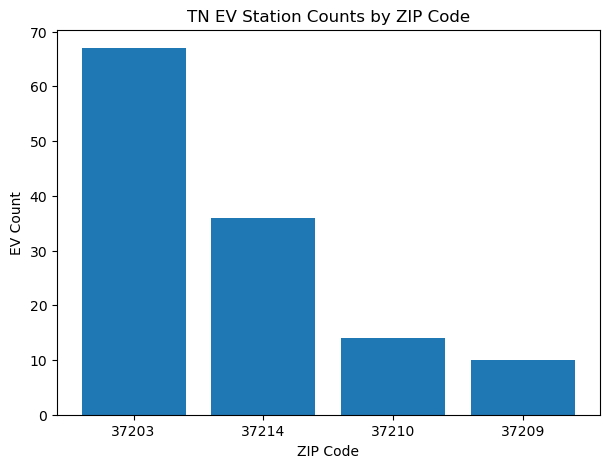

In [51]:
count_zips = {
    37203: 67,
    37214: 36,
    37210: 14,
    37209: 10
}

# If it's a dictionary → convert to Series
import pandas as pd
count_zips = pd.Series(count_zips)

# Bar chart
plt.figure(figsize=(7,5))
plt.bar(count_zips.index.astype(str), count_zips.values)

plt.title("TN EV Station Counts by ZIP Code")
plt.xlabel("ZIP Code")
plt.ylabel("EV Count")
plt.show()

In [52]:
#sns.barplot(data = count_zips, x= 'zip', y = 'count')

#df = pd.DataFrame(count_zips)

# Approximate center of Nashville (since those ZIPs are in Nashville, TN)
m = folium.Map(location=[36.1627, -86.7816], zoom_start=11)

# Add circles for each ZIP
for _, row in df.iterrows():
    # You’ll need a ZIP-to-lat/lon lookup (can use uszipcode or a CSV of ZIP centroids)
    # Here I’ll just put placeholder coordinates:
    lat, lon = 36.1627, -86.7816  # Replace with actual coords for each ZIP
    folium.CircleMarker(
        location=[lat, lon],
        radius=row["count"] / 5,   # scale circle size by EV count
        popup=f"ZIP: {row['zip']}<br>EV Count: {row['count']}",
        color="blue",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Save to HTML
m.save("ev_zip_map.html")

In [53]:
#37203    67-- 

In [54]:
stops_in_37203 = stops_by_zip.loc[stops_by_zip['zip'] == '37203']
stops_in_37203.shape

(67, 69)

In [55]:
zipcodes.loc[zipcodes['zip'] == '37203']

,zip,po_name,geometry
35,37203,NASHVILLE,"MULTIPOLYGON (((-86.78734 36.16688, -86.78711 ..."


In [56]:
polygon37203 = zipcodes.loc[zipcodes['zip'] == '37203']
polygon37203.shape

(1, 3)

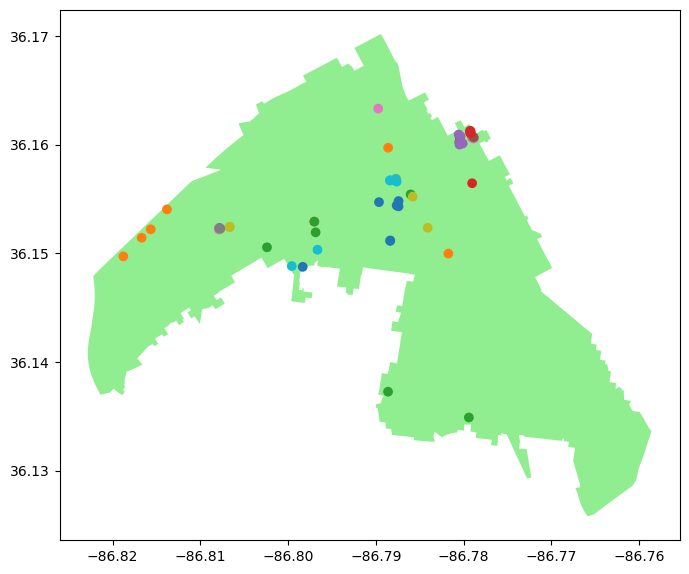

In [57]:
#fig, ax = matplotlib.subplots()
ax = polygon37203.plot(figsize = (8, 10), color = 'lightgreen')
stops_in_37203.plot( ax = ax, column = 'Station Name');
plt.show();

In [58]:
polygon37203.geometry.centroid

C:\Users\nainy\AppData\Local\Temp\ipykernel_30244\651956959.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  polygon37203.geometry.centroid


35    POINT (-86.78899 36.14860)
dtype: geometry

In [59]:
#find the center of the larger (more southern) polygon and look at it
center = polygon37203.geometry.centroid[35]
print(center)

POINT (-86.7889889966741 36.14860232841574)


C:\Users\nainy\AppData\Local\Temp\ipykernel_30244\3545517365.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = polygon37203.geometry.centroid[35]


In [60]:
# reverse the order when constructing the array for folium location
area_center = [center.y, center.x]

# check the order of area_center, the location for our folium map
print(area_center)

[36.14860232841574, -86.7889889966741]


In [61]:
#create our map of Nashville Zip Code 37207 and show it
map_37203 = folium.Map(location =  area_center, zoom_start = 12)
map_37203

In [62]:
stops_in_37203

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry,index_right,zip,po_name
4944,ELEC,HCA Corporate Headquarters - Building 1,One Park Plaza,,Nashville,TN,37203,,,E,,Private,Employee use only,,,,,,4,,,Non-Networked,,GPS,36.154030282867815,-86.81379926522062,2021-01-14,46470,2021-03-11 23:22:17 UTC,P,,,2011-07-15,,,,,J1772,US,,,,PrivÃ©,,private,,,OFFICE_BLDG,,,,,,,Free,,,,,,,,,SOLAR,,POINT (-86.81380 36.15403),35,37203,NASHVILLE
7158,ELEC,Vanderbilt University - Surface Lot,124 21st Ave S,,Nashville,TN,37212,,615-322-2554,E,,Public - Credit card at all times,24 hours daily; pay lot; Also accepts Vanderbi...,A D M V,,,,,10,,,Non-Networked,,200-9,36.148816,-86.799577,2021-01-14,52836,2021-03-11 23:22:17 UTC,P,,,2012-08-31,,,,,J1772,US,,,,Public - Carte de crÃ©dit en tout temps,,public,CREDIT_CARD_ALWAYS,,COLLEGE_CAMPUS,,,,,,,Free,,,,,,,,,SOLAR,,POINT (-86.79958 36.14882),35,37203,NASHVILLE
8689,ELEC,METRO NASHVILLE MIDTOWN HILLS,1441 12th Ave S,,Nashville,TN,37203,,888-758-4389,E,,Public,24 hours daily,,,,,,2,,,ChargePoint Network,http://www.chargepoint.com/,GPS,36.137258,-86.788609,2021-07-29,62807,2021-07-29 00:26:39 UTC,,,,2014-08-07,,,,,J1772,US,,,,Public,,public,,,,,,,,,,,,,,,,,,,,,POINT (-86.78861 36.13726),35,37203,NASHVILLE
11357,ELEC,Hutton Hotel,1808 W End Ave,,Nashville,TN,37203,,615-340-9333,E,,Public,24 hours daily; for guest use only; see valet ...,,,,,,1,,,Non-Networked,,200-9,36.152907,-86.797009,2020-09-03,72198,2021-03-11 23:22:17 UTC,P,,,2015-12-01,,,,,J1772,US,,,,Public,,public,,,HOTEL,,,,,,,,,,,,,,,,,,POINT (-86.79701 36.15291),35,37203,NASHVILLE
11489,ELEC,TRISTAR CENTENN HCPI STATION 2,2222 State St,,Nashville,TN,37203,,888-758-4389,E,,Public,24 hours daily,,,,,,2,,,ChargePoint Network,http://www.chargepoint.com/,GPS,36.152413,-86.806671,2021-07-29,73196,2021-07-29 00:26:39 UTC,,,,2016-01-28,,,,,J1772,US,,,,Public,,public,,,,,,,,,,,,,,,,,,,,,POINT (-86.80667 36.15241),35,37203,NASHVILLE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49016,ELEC,PP 5TH&BROAD 5+B_RESI02_5,612 Broadway,,Nashville,TN,37203,,888-758-4389,E,,Public,24 hours daily,,,,,,1,,,ChargePoint Network,http://www.chargepoint.com/,GPS,36.1601,-86.7801,2021-07-29,182255,2021-07-29 00:26:39 UTC,,,,2021-01-27,,,,,J1772,US,,,,Public,,public,,,,,,,,,,,,,,,,,,,,,POINT (-86.78010 36.16010),35,37203,NASHVILLE
49017,ELEC,PP 5TH&BROAD 5+B_RESI02_1,612 Broadway,,Nashville,TN,37203,,888-758-4389,E,,Public,24 hours daily,,,,,,2,,,ChargePoint Network,http://www.chargepoint.com/,GPS,36.159996,-86.78047,2021-07-29,182256,2021-07-29 00:26:39 UTC,,,,2021-01-27,,,,,J1772,US,,,,Public,,public,,,,,,,,,,,,,,,,,,,,,POINT (-86.78047 36.16000),35,37203,NASHVILLE
49018,ELEC,PP 5TH&BROAD 5+B_RESI02_2,118 7th Ave N,,Nash

In [63]:
i = 0
for row_index, row_values in stops_in_37203.iterrows():
    if i <3: 
        print('index is', row_index)
        print('values are:')
        print(' ')
        print(row_values)
        print('------------------------- ')
        i+=1

index is 4944
values are:
 
Fuel Type Code                                                      ELEC
Station Name                     HCA Corporate Headquarters - Building 1
Street Address                                            One Park Plaza
Intersection Directions                                                 
City                                                           Nashville
                                               ...                      
Restricted Access                                                       
geometry                   POINT (-86.81379926522062 36.154030282867815)
index_right                                                           35
zip                                                                37203
po_name                                                        NASHVILLE
Name: 4944, Length: 69, dtype: object
------------------------- 
index is 7158
values are:
 
Fuel Type Code                                            ELEC
Station Name 

In [64]:
#draw our zip code area: 37207
map_37203 = folium.Map(location =  area_center, zoom_start = 12)

folium.GeoJson(polygon37203).add_to(map_37203)

#iterate through stops_in_37207 to create locations and markers 
#for each bus stop
#remember for Folium locations, lat is listed first!!

for row_index, row_values in stops_in_37203.iterrows():
    loc = [row_values['Latitude'], row_values['Longitude']]
    pop = str(row_values['Station Name'])
    icon=folium.Icon(color="green",icon="gas-pump", prefix='fa')
    
    marker = folium.Marker(
        location = loc, 
        popup = pop, icon = icon) 

    marker.add_to(map_37203)
map_37203.save('../maps/map37203.html')

#display our map
map_37203

In [65]:
# show this map in EVs

In [66]:
#US Population states.

In [67]:
#https://www.kaggle.com/datasets/alexandrepetit881234/us-population-by-state

In [68]:
#2020_population_by_states_

In [69]:
pop_by_states= pd.read_csv("C:/Users/nainy/Documents/nss_dda16/python/projects/EV_Capstone_project_nainy/data/us_pop_by_state.csv")

In [70]:
pop_by_states

,rank,state,state_code,2020_census,percent_of_total
0,1.0,California,CA,39538223,0.1191
1,2.0,Texas,TX,29145505,0.0874
2,3.0,Florida,FL,21538187,0.0647
3,4.0,New York,NY,20201249,0.0586
4,5.0,Pennsylvania,PA,13002700,0.0386
5,6.0,Illinois,IL,12801989,0.0382
6,7.0,Ohio,OH,11799448,0.0352
7,8.0,Georgia,GA,10711908,0.0320
8,9.0,North Carolina,NC,10439388,0.0316
9,10.0,Michigan,MI,10077331,0.0301


In [71]:
pop_by_states.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              51 non-null     float64
 1   state             52 non-null     object 
 2   state_code        52 non-null     object 
 3   2020_census       52 non-null     int64  
 4   percent_of_total  51 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 2.2+ KB


In [72]:
pop_by_states['2020_census'].sum()

662903632

In [73]:
states_50_pop = pop_by_states.head(51)

In [74]:
states_50_pop.tail(5)

,rank,state,state_code,2020_census,percent_of_total
46,47.0,North Dakota,ND,779094,0.0023
47,48.0,Alaska,AK,733391,0.0022
48,49.0,DC,DC,689545,0.0021
49,50.0,Vermont,VT,643077,0.0019
50,51.0,Wyoming,WY,576851,0.0017


In [75]:
states_50_pop

,rank,state,state_code,2020_census,percent_of_total
0,1.0,California,CA,39538223,0.1191
1,2.0,Texas,TX,29145505,0.0874
2,3.0,Florida,FL,21538187,0.0647
3,4.0,New York,NY,20201249,0.0586
4,5.0,Pennsylvania,PA,13002700,0.0386
5,6.0,Illinois,IL,12801989,0.0382
6,7.0,Ohio,OH,11799448,0.0352
7,8.0,Georgia,GA,10711908,0.0320
8,9.0,North Carolina,NC,10439388,0.0316
9,10.0,Michigan,MI,10077331,0.0301


In [76]:
states_50_pop['2020_census'].sum()

331454351

In [77]:
total_us_pop = 331454351 

In [78]:
Elec_stations_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 47086 entries, 159 to 56793
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Fuel Type Code                    47086 non-null  object  
 1   Station Name                      47086 non-null  object  
 2   Street Address                    47086 non-null  object  
 3   Intersection Directions           47086 non-null  object  
 4   City                              47086 non-null  object  
 5   State                             47086 non-null  object  
 6   ZIP                               47086 non-null  object  
 7   Plus4                             47086 non-null  object  
 8   Station Phone                     47086 non-null  object  
 9   Status Code                       47086 non-null  object  
 10  Expected Date                     47086 non-null  object  
 11  Groups With Access Code           47086 non-null 

In [79]:
#Elec_stations_df.group(State

In [80]:
Elec_stations_df.head(5)

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
159,ELEC,LADWP - Truesdale Center,11797 Truesdale St,,Sun Valley,CA,91352,,,E,,Private,Fleet use only,,,,,,39,3,,Non-Networked,,GPS,34.2483191527193,-118.3879713743439,2021-07-14,1517,2021-07-14 18:51:43 UTC,LG,,,1999-10-15,,,,,CHADEMO J1772 J1772COMBO,US,,,,PrivÃ©,,private,,,UTILITY,,,,,,,,,,,,,,,,,,None
160,ELEC,LADWP - West LA District Office,1394 S Sepulveda Blvd,,Los Angeles,CA,90024,,,E,,Private,,,,,,,4,,,Non-Networked,,200-8,34.052542,-118.448504,2021-07-14,1519,2021-07-14 18:51:43 UTC,LG,,,2020-02-28,,,,,J1772,US,,,,PrivÃ©,,private,,,UTILITY,,,,,,,Free,,,,,,,,,,,None
161,ELEC,Southern California Edison - Rosemead Office B...,2244 Walnut Grove Ave,,Rosemead,CA,91770,,,T,2021-06-01,TEMPORARILY UNAVAILABLE (Private),Employee use only,,,,,22,22,,,Greenlots,http://greenlots.com/,200-9,34.050745,-118.081014,2021-01-14,1520,2021-03-11 23:22:17 UTC,T,,,2011-08-01,,,,,J1772 NEMA520,US,,,,TEMPORAIREMENT SUSPENDU (PrivÃ©),,private,,,UTILITY,,,,,,,,,,,,,,,,,,None
162,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,,213-741-1151,E,,Public,24 hours daily; pay lot,,,,,,12,,,Non-Networked,,GPS,34.040539,-118.271387,2020-11-09,1523,2021-03-11 23:22:17 UTC,P,,,1995-08-30,,,,,J1772,US,,,,Public,,public,,,PARKING_GARAGE,,,,,,,,,,,,,,,,,,None
163,ELEC,LADWP - John Ferraro Building,111 N Hope St,Across Hope,Los Angeles,CA,90012,,,E,,Private,For fleet and employee use only,,,,,,311,2,,Non-Networked,,GPS,34.059133,-118.248589,2021-07-14,1525,2021-07-14 18:51:43 UTC,LG,,,1999-10-15,,,,,CHADEMO J1772 J1772COMBO,US,,,,PrivÃ©,,private,,,UTILITY,,,,,,,,,,,,,,,,,,None


In [81]:
states_df= Elec_stations_df['State'].value_counts().reset_index()

In [82]:
states_df = states_df.rename(columns={'Count':'count_of_ev'})

In [83]:
states_df.shape


(52, 2)

In [84]:
states_df.head(3)

,State,count
0,CA,13892
1,NY,2756
2,FL,2506


In [85]:
states_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   State   52 non-null     object
 1   count   52 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 960.0+ bytes


In [86]:
states_50_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              51 non-null     float64
 1   state             51 non-null     object 
 2   state_code        51 non-null     object 
 3   2020_census       51 non-null     int64  
 4   percent_of_total  51 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 2.1+ KB


In [87]:
Elec_stations_df.head(2)



,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,geometry
159,ELEC,LADWP - Truesdale Center,11797 Truesdale St,,Sun Valley,CA,91352,,,E,,Private,Fleet use only,,,,,,39,3,,Non-Networked,,GPS,34.2483191527193,-118.3879713743439,2021-07-14,1517,2021-07-14 18:51:43 UTC,LG,,,1999-10-15,,,,,CHADEMO J1772 J1772COMBO,US,,,,PrivÃ©,,private,,,UTILITY,,,,,,,,,,,,,,,,,,None
160,ELEC,LADWP - West LA District Office,1394 S Sepulveda Blvd,,Los Angeles,CA,90024,,,E,,Private,,,,,,,4,,,Non-Networked,,200-8,34.052542,-118.448504,2021-07-14,1519,2021-07-14 18:51:43 UTC,LG,,,2020-02-28,,,,,J1772,US,,,,PrivÃ©,,private,,,UTILITY,,,,,,,Free,,,,,,,,,,,None


In [88]:
states_df.columns = states_df.columns.str.strip()   # remove spaces
states_50_pop.columns = states_50_pop.columns.str.strip()

states_df.columns = states_df.columns.str.title()   # make case consistent
states_50_pop.columns = states_50_pop.columns.str.title()

In [89]:
states_df.head(3)

,State,Count
0,CA,13892
1,NY,2756
2,FL,2506


In [90]:
states_50_pop.head(3)

,Rank,State,State_Code,2020_Census,Percent_Of_Total
0,1.0,California,CA,39538223,0.1191
1,2.0,Texas,TX,29145505,0.0874
2,3.0,Florida,FL,21538187,0.0647


In [91]:
Merged_df_state_and_ev_count = pd.merge(states_df, states_50_pop, how ='inner',left_on = 'State' , right_on = 'State_Code')

In [92]:
Merged_df_state_and_ev_count

,State_x,Count,Rank,State_y,State_Code,2020_Census,Percent_Of_Total
0,CA,13892,1.0,California,CA,39538223,0.1191
1,NY,2756,4.0,New York,NY,20201249,0.0586
2,FL,2506,3.0,Florida,FL,21538187,0.0647
3,TX,2199,2.0,Texas,TX,29145505,0.0874
4,MA,1889,15.0,Massachusetts,MA,7029917,0.0209
5,WA,1686,13.0,Washington,WA,7705281,0.0229
6,GA,1548,8.0,Georgia,GA,10711908,0.0320
7,CO,1488,21.0,Colorado,CO,5773714,0.0174
8,MD,1173,18.0,Maryland,MD,6177224,0.0185
9,PA,1081,5.0,Pennsylvania,PA,13002700,0.0386


In [93]:
Merged_df_state_and_ev_count.corr(numeric_only = True)

,Count,Rank,2020_Census,Percent_Of_Total
Count,1.000000,-0.474051,0.816174,0.819121
Rank,-0.474051,1.000000,-0.786382,-0.784039
2020_Census,0.816174,-0.786382,1.000000,0.999880
Percent_Of_Total,0.819121,-0.784039,0.999880,1.000000


Diagonal is 1.0 → any variable with itself has perfect correlation.

Count_Of_Ev vs 2020_Census (0.816) → strong positive correlation. More census population tends to mean more EVs.

Count_Of_Ev vs Percent_Of_Total (0.819) → also strongly positive.

Rank vs 2020_Census (-0.786) → strong negative correlation (lower rank number = higher population).

Rank vs Count_Of_Ev (-0.474) → moderate negative correlation (states with higher EV counts tend to have a better rank).

import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix automatically
corr = Merged_df_state_and_ev_count.corr()

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

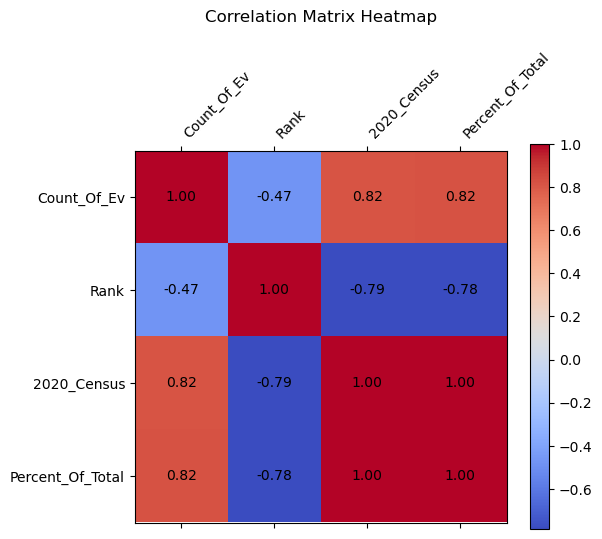

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Correlation matrix data
corr_data = {
    "Count_Of_Ev": [1.000000, -0.474051, 0.816174, 0.819121],
    "Rank":        [-0.474051, 1.000000, -0.786382, -0.784039],
    "2020_Census": [0.816174, -0.786382, 1.000000, 0.999880],
    "Percent_Of_Total": [0.819121, -0.784039, 0.999880, 1.000000]
}
corr_df = pd.DataFrame(
    corr_data, 
    index=["Count_Of_Ev", "Rank", "2020_Census", "Percent_Of_Total"]
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(corr_df, cmap="coolwarm")

# Axis labels
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="left")
plt.yticks(range(len(corr_df.index)), corr_df.index)

# Add colorbar
fig.colorbar(cax)

# Add correlation values inside heatmap
for (i, j), val in np.ndenumerate(corr_df.values):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap", pad=20)
plt.show()